# 3. Exploratory data analysis and visualisation

Before a single model is fitted, a data scientist spends hours — often days — simply
*looking* at the data. That is not procrastination; it is where most of the value of a
project is created or lost. Exploratory data analysis (EDA) is how you learn what a row
means, which columns are trustworthy, how the target behaves, which features carry
information about it, and which traps (duplicates, leaked columns, impossible values,
selection effects) are waiting for the unwary. A model trained on data you have not
looked at is a model whose failures you will not understand.

This notebook develops a disciplined EDA workflow and the visual vocabulary that goes with
it. We work through the raw customer-churn table that notebook 1 loaded, take a first look
at a multivariate data set (`load_wine`) and at a time series (`load_energy_demand()`), and
finish with the classic ways in which data and charts mislead. The tools are pandas,
Matplotlib (Hunter, 2007) and seaborn (Waskom, 2021); the attitude comes from Tukey (1977).

**Prerequisites:** notebook 1 (pandas: selection, `groupby`, `pivot_table`, `.dt`/`.str`
accessors) and the descriptive statistics of notebook 2 (mean, variance, quantiles,
correlation).

## Learning objectives

After working through this notebook you will be able to

- run a first-contact inspection of any table (shape, types, memory, summaries, cardinality, missingness, duplicates, inconsistent categories, impossible values) and write down the data-quality findings;
- choose the right univariate plot (histogram, KDE, box, violin, bar) and know how bin width, log scales and robust statistics change what you see;
- detect outliers with the IQR rule and $z$-scores, and explain when each fails;
- compare Pearson, Spearman and Kendall correlation, reproduce Anscombe's quartet, and explain why correlation is neither causation nor the whole story;
- analyse relationships between numeric and categorical variables (grouped box plots, conditional means with confidence intervals, cross-tabs, normalised stacked bars) and carry out target-oriented EDA;
- use pair plots, facets, parallel coordinates and PCA as multivariate lenses;
- explore a time series with resampling, rolling means and seasonal profiles;
- recognise Simpson's paradox, survivorship and selection bias, and misleading axes — and produce charts that follow the grammar of good graphics (Tufte, 2001; Wilke, 2019).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns          # statistical plots on top of matplotlib (KDEs, box/violin plots, heatmaps, pair plots)
from scipy import stats        # correlation coefficients and statistical tests

# course helpers: plot style, colour list, and loaders for the churn table and the hourly energy-demand data
from course_utils import set_style, PALETTE, load_churn, load_energy_demand

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)    # seeded random-number generator (used for jitter and simulations)
set_style()

## 1. Why EDA, and what a good chart looks like

John Tukey, who coined the term, described exploratory data analysis as detective work:
looking at the data with an open mind to see what they seem to say, *before* confirmatory
analysis tests specific hypotheses (Tukey, 1977). In a machine-learning project the
detective's questions are concrete:

1. **What is a row?** One customer, one transaction, one customer-month? Are rows
   independent, or grouped (several rows per customer) or ordered in time?
2. **What is the target,** how is it distributed, and could it have leaked into any feature
   (a column that is only known *after* the outcome)?
3. **What is each column** — its type, its unit, its meaning, its plausible range?
4. **What is missing,** how much, and *why* (at random, or for a reason that correlates
   with the target)?
5. **How is each variable distributed?** Skew, modes, outliers, impossible values.
6. **How do variables relate** to each other and to the target?
7. **Is the sample representative** of the population the model will be used on?

The answers drive every later decision: cleaning and imputation (notebook 4), the choice
of metric and validation scheme (notebook 5), feature engineering, and which model family
is even plausible.

### 1.1 The grammar of a good chart

A chart maps data to visual *encodings* — position along an axis, length, area, colour,
shape. Not all encodings are equal: people compare positions on a common scale most
accurately, lengths and angles less so, areas and colour intensities worst of all
(Cleveland & McGill, 1984). That single result explains most rules of thumb: bar charts
and dot plots beat pie charts; a shared axis beats a colour scale; small multiples beat one
crowded panel. Tufte (2001) adds the aesthetic discipline — maximise the *data–ink ratio*,
remove chart junk, do not distort (his "lie factor" is the ratio of the visual effect to the
effect in the data) — and Wilke (2019) is the modern, practical guide to choosing the right
plot for the question. Wickham (2010) formalised the idea of a *layered grammar* in which
data, aesthetic mappings, geometric marks, scales and facets are composed; seaborn's
figure-level functions follow this philosophy.

Every chart in this course follows the same conventions, set by `course_utils.set_style()`:
a colour-blind-safe categorical palette (`PALETTE`, related to the Okabe–Ito palette;
Okabe & Ito, 2008), `viridis` for sequential quantities, `RdBu_r` centred at zero for signed
ones, a title, labelled axes with units, a legend whenever there are two or more series,
and no dual $y$-axes.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


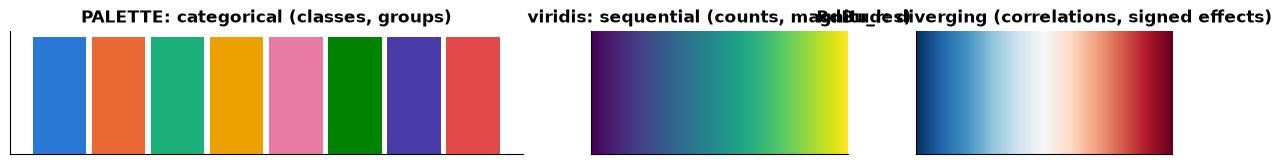

In [2]:
# three panels side by side; width_ratios makes the first one twice as wide as the others
fig, axes = plt.subplots(1, 3, figsize=(15, 1.6), gridspec_kw={"width_ratios": [2, 1, 1]})
axes[0].bar(range(len(PALETTE)), np.ones(len(PALETTE)), color=PALETTE, width=0.9)   # one equal-height bar per colour
axes[0].set_title("PALETTE: categorical (classes, groups)")
gradient = np.linspace(0, 1, 256)[None, :]     # [None, :] adds a first axis: shape (1, 256), a one-row "image"
axes[1].imshow(gradient, aspect="auto", cmap="viridis")    # aspect="auto" stretches the single row to fill the panel
axes[1].set_title("viridis: sequential (counts, magnitudes)")
axes[2].imshow(gradient, aspect="auto", cmap="RdBu_r")     # the "_r" suffix reverses a colour map (red = high)
axes[2].set_title("RdBu_r: diverging (correlations, signed effects)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
plt.show()

## 2. Data at first sight

We take the churn table exactly as it comes out of the export — `load_churn(raw=True)`,
the same file as `../data/customer_churn.csv` — and interrogate it before trusting it.

In [3]:
raw = load_churn(raw=True)        # the CSV exactly as shipped, with all its problems
print("shape:", raw.shape)
# memory_usage(deep=True) also counts the text stored in string columns; .sum() adds up all columns (bytes -> kB)
print(f"memory: {raw.memory_usage(deep=True).sum() / 1e3:.0f} kB")
print(raw.dtypes.to_string())     # .to_string() prints every row instead of an abbreviated view
display(raw.head(3))              # display() renders a table even when it is not the last line of the cell
raw.sample(3, random_state=RANDOM_STATE)      # a random sample is often more revealing than the first rows

shape: (5005, 15)
memory: 808 kB
customer_id                    str
signup_date         datetime64[us]
region                         str
senior_citizen               int64
has_partner                  int64
tenure_months                int64
contract                       str
payment_method                 str
internet_service               str
tech_support                 int64
streaming                    int64
monthly_charges            float64
total_charges              float64
support_tickets              int64
churned                      int64


,customer_id,signup_date,region,senior_citizen,has_partner,tenure_months,contract,payment_method,internet_service,tech_support,streaming,monthly_charges,total_charges,support_tickets,churned
0,C00001,2023-01-26,North,0,0,17,One year,Bank transfer,DSL,0,0,52.96,880.42,0,0
1,C00002,2023-12-15,South,0,1,6,Month-to-month,Bank transfer,Fiber optic,1,0,92.90,NaN,1,1
2,C00003,2023-11-02,West,1,1,8,Two year,Electronic check,Fiber optic,0,0,84.57,696.84,2,1


,customer_id,signup_date,region,senior_citizen,has_partner,tenure_months,contract,payment_method,internet_service,tech_support,streaming,monthly_charges,total_charges,support_tickets,churned
3704,C03705,2024-02-14,North,0,0,4,Month-to-month,Electronic check,Fiber optic,1,0,91.36,381.52,1,1
3253,C03254,2024-03-27,South,0,1,3,Month-to-month,Electronic check,No,0,0,20.34,59.79,2,1
4420,C04421,2024-04-29,South,0,1,2,Month-to-month,Credit card,DSL,0,1,69.76,138.55,1,1


`head()` shows the first rows, which are often unrepresentative (sorted by date, or by
ID); `sample()` gives a random glimpse; `tail()` catches trailing junk such as summary
rows. Next, the summaries — numeric columns with `describe()`, text columns with the number
of distinct values and the most frequent one:

In [4]:
# describe() summarises every numeric (and date) column: count, mean, std, min, quartiles, max; .T puts columns in rows
display(raw.describe().T.round(2))
text_cols = raw.select_dtypes(include=["str", "object"]).columns    # the names of the text columns
# one row per text column: number of distinct values, most frequent value, its count, and up to four example values
summary = pd.DataFrame({
    "n_unique": raw[text_cols].nunique(),
    "top": raw[text_cols].mode().iloc[0],            # mode() lists the most frequent value(s); row 0 is the first
    "top_freq": [raw[c].value_counts().iloc[0] for c in text_cols],   # value_counts() is sorted, so .iloc[0] is the top
    # .unique() keeps the distinct values in order of appearance; map(str, ...) converts them so join() can glue them
    "examples": [", ".join(map(str, raw[c].unique()[:4])) for c in text_cols],
})
summary

,count,mean,min,25%,50%,75%,max,std
signup_date,5005,2022-02-07 02:48:01.438561,2018-07-03 00:00:00,2021-01-26 00:00:00,2022-07-14 00:00:00,2023-06-19 00:00:00,2024-06-30 00:00:00,NaN
senior_citizen,5005.0,0.158841,0.0,0.0,0.0,0.0,1.0,0.365564
has_partner,5005.0,0.483716,0.0,0.0,0.0,1.0,1.0,0.499785
tenure_months,5005.0,28.645954,0.0,12.0,23.0,41.0,72.0,20.637069
tech_support,5005.0,0.290709,0.0,0.0,0.0,1.0,1.0,0.454135
streaming,5005.0,0.367433,0.0,0.0,0.0,1.0,1.0,0.482154
monthly_charges,5005.0,69.474653,15.0,55.01,71.59,91.79,999.0,35.697261
total_charges,4851.0,1984.953354,15.54,647.255,1422.91,2846.665,9028.77,1734.292326
support_tickets,5005.0,1.00979,0.0,0.0,1.0,2.0,8.0,1.156129
churned,5005.0,0.326474,0.0,0.0,0.0,1.0,1.0,0.46897


,n_unique,top,top_freq,examples
customer_id,5000,C00706,2,"C00001, C00002, C00003, C00004"
region,8,West,1267,"North, South, West, East"
contract,3,Month-to-month,2795,"One year, Month-to-month, Two year"
payment_method,4,Electronic check,1694,"Bank transfer, Electronic check, Mailed check,..."
internet_service,3,Fiber optic,2115,"DSL, Fiber optic, No"


Read summaries like a detective. `customer_id` has 5 000 distinct values in 5 005 rows —
duplicates. `region` has 8 distinct values where 4 are expected. `monthly_charges` has a
maximum of 999 while its 75th percentile is below 100. `total_charges` has 4 851 non-null
values out of 5 005. `tenure_months` runs from 0 to 72 — is 72 a real maximum or a cap?
Each of these is a lead to follow.

### 2.1 Missingness

Counting missing values is the first step; the second is finding out **whether the
missingness has structure**. A *missingness matrix* — rows × columns, coloured where a
value is absent — makes patterns visible, especially after sorting the rows by a candidate
explanatory variable. Whether values are missing completely at random (MCAR), at random
given the observed data (MAR), or not at random (MNAR; Rubin, 1976) decides which
imputation strategies are valid (notebook 4).

missing values per column:
total_charges    154
rows with any missing value: 154 (3.1%)


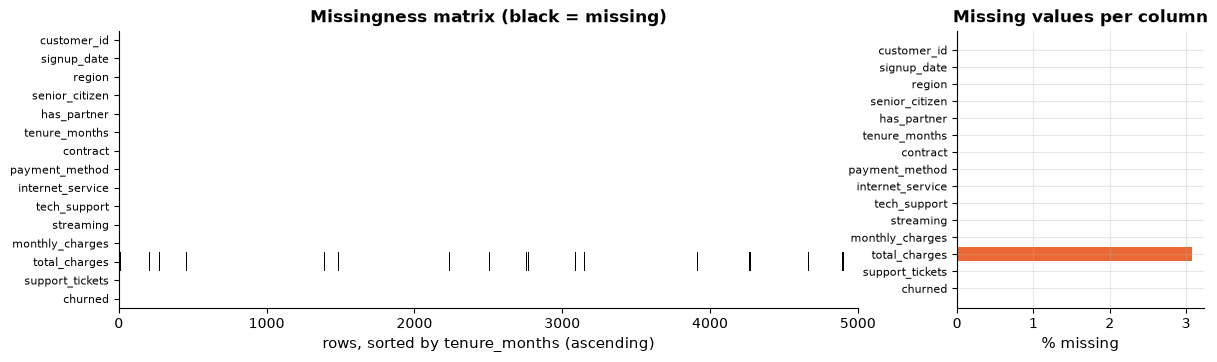

total_charges missing  False  True 
tenure == 0                        
False                   4851    138
True                       0     16


In [5]:
missing = raw.isna()                      # a True/False frame: True where a value is missing
counts = missing.sum()                    # True counts as 1, so this is the number of missing values per column
print("missing values per column:")
print(counts[counts > 0].to_string())
# .any(axis=1) is True for rows with at least one missing value; its .mean() is the share of such rows
print(f"rows with any missing value: {missing.any(axis=1).sum()} ({missing.any(axis=1).mean():.1%})")

# np.argsort returns the row positions that would sort the column; "stable" keeps tied rows in their original order
order = np.argsort(raw["tenure_months"].to_numpy(), kind="stable")          # sort rows by tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), gridspec_kw={"width_ratios": [3, 1]})
# reorder the rows, then transpose so that every column of the table becomes one horizontal line of pixels
axes[0].imshow(missing.to_numpy()[order].T, aspect="auto", cmap="Greys", interpolation="nearest")
axes[0].set_yticks(range(raw.shape[1]))
axes[0].set_yticklabels(raw.columns, fontsize=8)
axes[0].set_xlabel("rows, sorted by tenure_months (ascending)")
axes[0].set_title("Missingness matrix (black = missing)")
axes[0].grid(False)
# [::-1] reverses the order, so that barh (which draws from the bottom up) lists the first column at the top
axes[1].barh(counts.index[::-1], (counts / len(raw) * 100)[::-1], color=PALETTE[1])
axes[1].set_xlabel("% missing")
axes[1].set_title("Missing values per column")
axes[1].tick_params(axis="y", labelsize=8)
plt.show()

# pd.crosstab counts the rows for each combination of the two True/False conditions
print(pd.crosstab(raw["tenure_months"] == 0, raw["total_charges"].isna(),
                  rownames=["tenure == 0"], colnames=["total_charges missing"]))

Only `total_charges` is affected, but not at random: *every* customer with zero tenure has
no total charge (no invoice has been issued yet — a structural, perfectly explainable gap),
plus about 3 % of the others, scattered evenly. The two mechanisms deserve different
treatment: the first is really "0 so far", the second is a random gap that can be imputed.

### 2.2 Duplicates, inconsistent categories and impossible values

In [6]:
# .duplicated() marks rows that repeat an earlier row (whole row, or here also just the customer_id column)
print(f"exact duplicate rows: {raw.duplicated().sum()}; duplicated customer_id: {raw['customer_id'].duplicated().sum()}")
print("\nregion spellings:", raw["region"].value_counts().to_dict())    # {value: count} for every distinct value
print("\ncustomers with monthly_charges > 200:")
display(raw.loc[raw["monthly_charges"] > 200, ["customer_id", "internet_service", "monthly_charges", "total_charges", "tenure_months"]])
print("tenure of 72 months (the maximum):", (raw["tenure_months"] == 72).sum(), "customers -> a cap, not a coincidence")
# a cross-column check: the total bill should be roughly monthly charge x months; keep three entries of describe()
consistency = (raw["total_charges"] / (raw["monthly_charges"] * raw["tenure_months"])).describe()[["min", "50%", "max"]]
print("\ntotal_charges / (monthly_charges x tenure) — should be about 1:", consistency.round(3).to_dict())

exact duplicate rows: 5; duplicated customer_id: 5

region spellings: {'West': 1267, 'East': 1259, 'North': 1242, 'South': 1187, 'south': 17, 'east': 12, 'west': 12, 'north': 9}

customers with monthly_charges > 200:


,customer_id,internet_service,monthly_charges,total_charges,tenure_months
1111,C01112,DSL,999.0,143.07,2
1821,C01822,No,999.0,171.87,8
3616,C03617,Fiber optic,999.0,279.44,3


tenure of 72 months (the maximum): 370 customers -> a cap, not a coincidence

total_charges / (monthly_charges x tenure) — should be about 1: {'min': 0.022, '50%': 1.001, 'max': 1.05}


Every finding goes into a **data-quality log**: what was found, how it was diagnosed,
what was decided. For the rest of this notebook we apply the three fixes that are beyond
doubt — drop the exact duplicates, normalise the spelling of `region`, and treat the
impossible `monthly_charges` values as missing — which is exactly what `load_churn()`
does. Everything else (imputation, the tenure cap, type conversions) is the business of
notebook 4.

In [7]:
# a method chain, one step per line (the outer brackets let the expression span several lines):
#   drop_duplicates(subset=...) keeps the first row of each customer_id
#   assign(...) replaces two columns: .str.strip() removes surrounding spaces and .str.title() capitalises
#   ("south" -> "South"); .mask(cond) replaces the values where cond is True with NaN
#   reset_index(drop=True) renumbers the rows 0..n-1 and discards the old row numbers
df = (raw.drop_duplicates(subset="customer_id")
         .assign(region=lambda d: d["region"].str.strip().str.title(),
                 monthly_charges=lambda d: d["monthly_charges"].mask(d["monthly_charges"] > 200))
         .reset_index(drop=True))
print("after light cleaning:", df.shape, "| regions:", sorted(df["region"].unique()),
      "| max monthly_charges:", df["monthly_charges"].max())
print(f"churn rate (the base rate every later comparison is measured against): {df['churned'].mean():.3f}")

after light cleaning: (5000, 15) | regions: ['East', 'North', 'South', 'West'] | max monthly_charges: 120.16
churn rate (the base rate every later comparison is measured against): 0.326


## 3. Univariate analysis

### 3.1 Histograms and density estimates

A histogram counts observations in bins; its shape depends on the bin width more than most
people expect. Too few bins hide structure, too many show noise. Always try several — the
default (`bins="auto"`, a compromise between the Sturges and Freedman–Diaconis rules) is a
starting point, not an answer. A **kernel density estimate** (KDE) smooths the histogram
with a Gaussian kernel; its bandwidth plays the role of the bin width, and it can invent
mass where none exists (negative charges, values beyond a hard boundary).

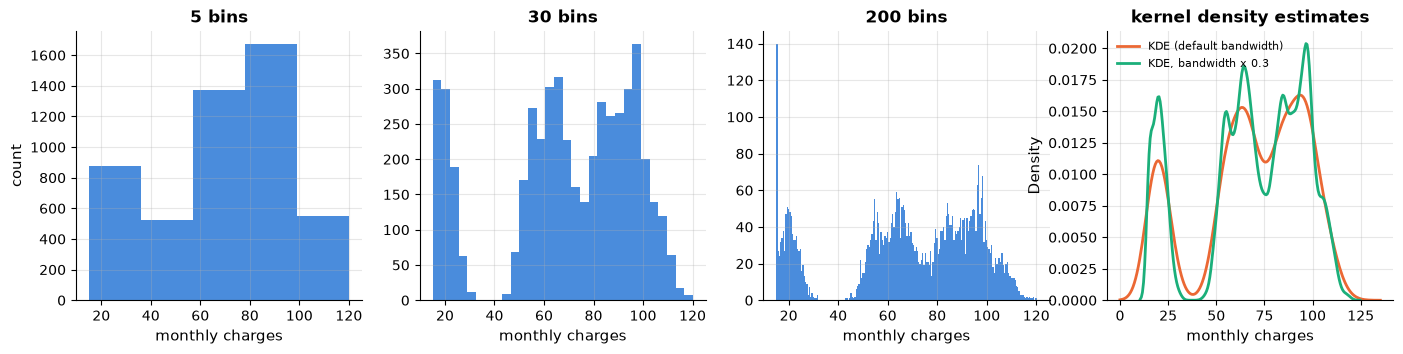

In [8]:
x = df["monthly_charges"].dropna()        # .dropna() removes the missing values
fig, axes = plt.subplots(1, 4, figsize=(17, 3.5), sharey=False)
for ax, bins in zip(axes[:3], [5, 30, 200]):      # the same data with three different numbers of bins
    ax.hist(x, bins=bins, color=PALETTE[0], alpha=0.85)
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("monthly charges")
axes[0].set_ylabel("count")
# sns.kdeplot draws a smoothed density curve; bw_adjust multiplies the automatically chosen bandwidth
sns.kdeplot(x, ax=axes[3], color=PALETTE[1], lw=2, label="KDE (default bandwidth)")
sns.kdeplot(x, ax=axes[3], color=PALETTE[2], lw=2, bw_adjust=0.3, label="KDE, bandwidth x 0.3")
axes[3].set_title("kernel density estimates")
axes[3].set_xlabel("monthly charges")
axes[3].legend(fontsize=8)
plt.show()

With 5 bins the distribution looks like one broad hump; with 30 it is clearly
**trimodal**, and the modes sit near 20, 55 and 85 — the base prices of the three internet
plans (none, DSL, fibre), each spread by add-ons. A summary statistic such as "mean 69"
would have described no actual customer.

### 3.2 Skewed data and log scales

Many quantities — incomes, charges accumulated over time, counts, file sizes — are
**right-skewed**: most values are small, a few are huge, and the mean is dragged above the
median. On a linear axis such data pile up at the left; a **logarithmic axis** (or a
log-transformed variable) spreads them out and often reveals a roughly symmetric shape.
Notebook 4 uses log and Box–Cox transforms as preprocessing for exactly this reason.
Counts with a small range (support tickets: 0 to 8) are discrete and belong in a bar chart
of value counts, not a histogram with arbitrary bins.

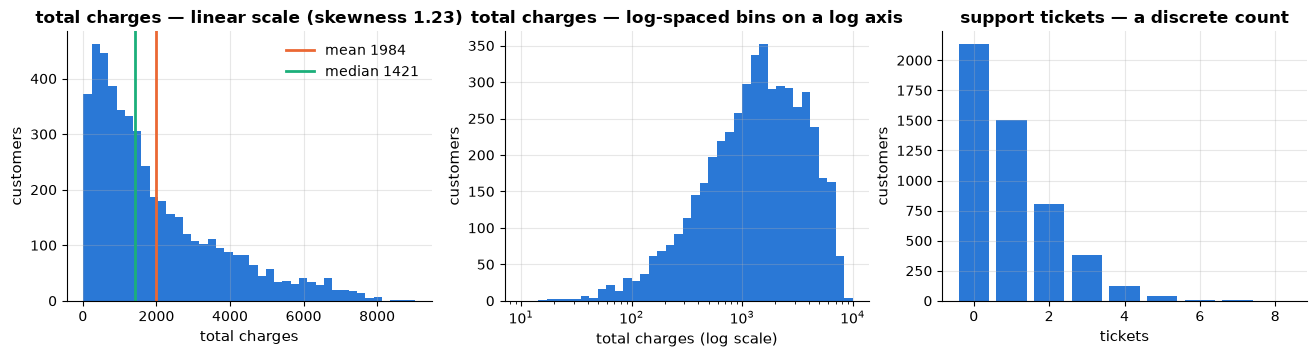

In [9]:
total = df["total_charges"].dropna()
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
axes[0].hist(total, bins=40, color=PALETTE[0])
axes[0].axvline(total.mean(), color=PALETTE[1], label=f"mean {total.mean():.0f}")      # vertical reference lines
axes[0].axvline(total.median(), color=PALETTE[2], label=f"median {total.median():.0f}")
# .skew() is the sample skewness: > 0 means a long right tail
axes[0].set_title(f"total charges — linear scale (skewness {total.skew():.2f})")
axes[0].set_xlabel("total charges")
axes[0].legend()
# bins can also be a list of edges: np.logspace(1, 4, 40) gives 40 edges from 10 to 10 000, evenly spaced on a log scale
axes[1].hist(total[total > 0], bins=np.logspace(1, 4, 40), color=PALETTE[0])
axes[1].set_xscale("log")
axes[1].set_title("total charges — log-spaced bins on a log axis")
axes[1].set_xlabel("total charges (log scale)")
tickets = df["support_tickets"].value_counts().sort_index()     # customers per number of tickets, ordered 0, 1, 2, ...
axes[2].bar(tickets.index, tickets.values, color=PALETTE[0])
axes[2].set_title("support tickets — a discrete count")
axes[2].set_xlabel("tickets")
for ax in axes:
    ax.set_ylabel("customers")
plt.show()

### 3.3 Box plots, violin plots and what they hide

A **box plot** summarises a distribution with five numbers: the median (line), the first
and third quartiles (box edges — the box spans the interquartile range, IQR), whiskers to
the most extreme points within $1.5 \times$ IQR of the box, and individual markers beyond
that ("outliers" by this convention). It is compact and excellent for comparing many
groups side by side — but it cannot show *shape*. A **violin plot** draws a KDE on each
side and reveals modes. Use the box for many groups, the violin when shape matters, and
overlay the raw points (`stripplot`/`swarmplot`) when there are few observations.

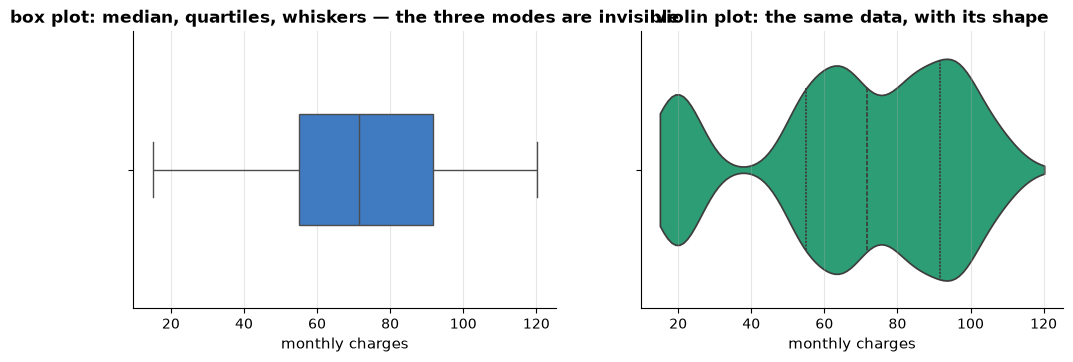

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
sns.boxplot(x=x, ax=axes[0], color=PALETTE[0], width=0.4)    # passing the data as x= draws a horizontal box
axes[0].set_title("box plot: median, quartiles, whiskers — the three modes are invisible")
# inner="quartile" draws the quartiles as lines inside the violin; cut=0 stops the density at the data's min and max
sns.violinplot(x=x, ax=axes[1], color=PALETTE[2], inner="quartile", cut=0)
axes[1].set_title("violin plot: the same data, with its shape")
for ax in axes:
    ax.set_xlabel("monthly charges")
plt.show()

### 3.4 Categorical variables

For a categorical variable the "distribution" is a table of counts. Bar charts with
categories sorted by frequency (or in their natural order for ordinal variables) are the
right display; horizontal bars leave room for long labels. Pie charts encode the same
information as angles and areas, which readers judge poorly — avoid them.

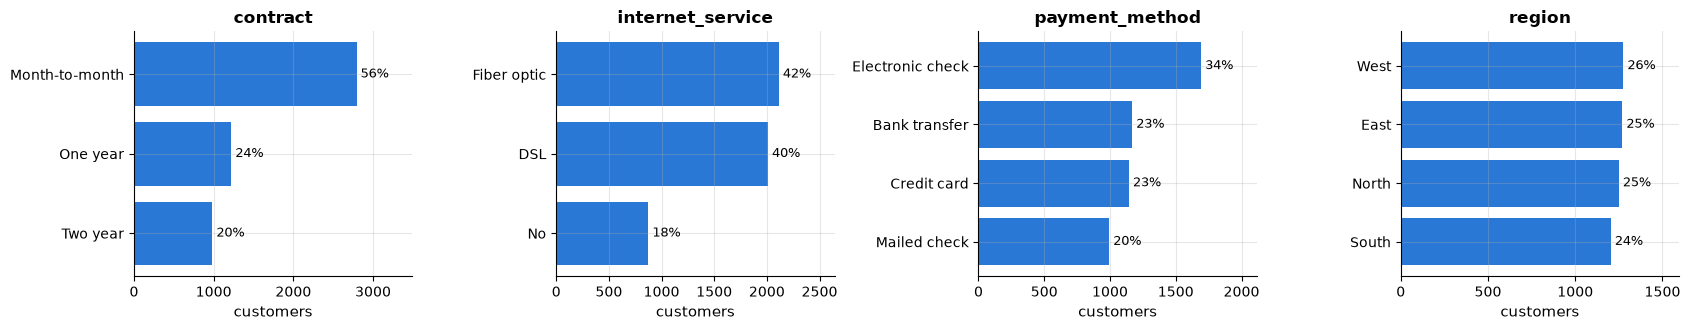

In [11]:
cat_cols = ["contract", "internet_service", "payment_method", "region"]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.4))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()                       # counts per category, largest first
    ax.barh(vc.index[::-1], vc.values[::-1], color=PALETTE[0])   # reversed, so the largest bar ends up at the top
    ax.set_title(col)
    ax.set_xlabel("customers")
    for i, v in enumerate(vc.values[::-1]):
        ax.text(v, i, f" {v / len(df):.0%}", va="center", fontsize=9)   # the share, written just right of each bar
    ax.set_xlim(0, vc.max() * 1.25)                   # room for the labels
plt.tight_layout()
plt.show()

### 3.5 Robust statistics and outlier detection

The mean and the standard deviation are the right summaries for roughly symmetric,
well-behaved data — and the wrong ones as soon as a few extreme values appear, because a
single point can move them arbitrarily far. **Robust** alternatives have a *breakdown
point*: the median and the IQR are unaffected until more than 25 % (median: 50 %) of the
data are corrupted, and the **median absolute deviation** $\operatorname{MAD} =
\operatorname{median}(|x_i - \operatorname{median}(x)|)$ (multiplied by 1.4826 to estimate
$\sigma$ for Gaussian data) is a robust scale. Compare the raw column, with its three
values of 999, to the cleaned one:

In [12]:
def summarise(s):
    """Classical and robust summaries of a numeric Series (missing values ignored), returned as a Series."""
    s = s.dropna()
    return pd.Series({"mean": s.mean(), "median": s.median(), "std": s.std(),
                      "IQR": s.quantile(0.75) - s.quantile(0.25),        # interquartile range Q3 - Q1
                      "MAD x 1.4826": 1.4826 * (s - s.median()).abs().median()})   # median absolute deviation, scaled

# a dict of Series becomes a DataFrame with one column per key
pd.DataFrame({"raw (3 values of 999)": summarise(raw["monthly_charges"]),
              "cleaned": summarise(df["monthly_charges"])}).round(2)

,raw (3 values of 999),cleaned
mean,69.47,68.92
median,71.59,71.59
std,35.70,27.51
IQR,36.78,36.69
MAD x 1.4826,27.03,27.03


Three bad values out of 5 005 shift the mean by half a unit and inflate the standard
deviation by 30 %; the median, IQR and MAD do not move. The same logic applies to
**outlier detection**:

- The **IQR rule** flags $x < Q_1 - 1.5\,\mathrm{IQR}$ or $x > Q_3 + 1.5\,\mathrm{IQR}$
  (the box-plot convention). Robust, but blind to what "normal" means for discrete or
  multimodal data.
- The **$z$-score rule** flags $|x - \bar{x}| / s > 3$. It uses the very statistics that
  outliers corrupt: a few extreme points inflate $s$ so much that they *mask* each other
  (and everything else). A robust $z$-score, $(x - \operatorname{median}) / (1.4826\,\mathrm{MAD})$,
  avoids the masking.

Neither rule knows the domain. A value of 999 is impossible for a monthly charge — the
data dictionary, not a statistic, tells us that. A customer with 8 support tickets is
unusual but real, and dropping such rows would remove exactly the customers a churn model
must learn about. Outlier detection as a *modelling* task (isolation forests, local
outlier factor) is the subject of notebook 13.

In [13]:
def iqr_flags(s, k=1.5):
    """True for the values of s below Q1 - k IQR or above Q3 + k IQR (the box-plot rule)."""
    q1, q3 = s.quantile([0.25, 0.75])        # quantile with a list returns two values, unpacked into q1 and q3
    return (s < q1 - k * (q3 - q1)) | (s > q3 + k * (q3 - q1))     # | is the element-wise "or"

def z_flags(s, threshold=3.0):
    """True for the values more than `threshold` standard deviations from the mean."""
    return ((s - s.mean()) / s.std()).abs() > threshold

def robust_z_flags(s, threshold=3.0):
    """Like z_flags, but centred on the median and scaled by 1.4826 x MAD, which outliers cannot inflate."""
    return ((s - s.median()) / (1.4826 * (s - s.median()).abs().median())).abs() > threshold

for name, s in [("monthly_charges, raw", raw["monthly_charges"]), ("monthly_charges, cleaned", df["monthly_charges"].dropna()),
                ("support_tickets", df["support_tickets"].astype(float))]:
    # summing a True/False Series counts the flagged values; :3d pads each count to 3 characters
    print(f"{name:26s} IQR rule: {iqr_flags(s).sum():3d}   z-score: {z_flags(s).sum():3d}   robust z: {robust_z_flags(s).sum():3d}")

monthly_charges, raw       IQR rule:   3   z-score:   3   robust z:   3
monthly_charges, cleaned   IQR rule:   0   z-score:   0   robust z:   0
support_tickets            IQR rule:  14   z-score:  54   robust z:  14


On the raw column the $z$-score catches the three 999s (they are far enough out even with
the inflated $s$), the IQR rule catches them too; on the cleaned, trimodal column nothing is
flagged. For support tickets the IQR rule flags every customer with five or more tickets,
while the robust $z$-score divides by a MAD of zero (more than half the customers have 0
or 1 ticket) and flags everything above the median — a reminder that these rules are
heuristics for continuous data, not oracles.

## 4. Bivariate analysis

### 4.1 Scatter plots: overplotting, transparency, jitter

The scatter plot is the fundamental display of a relationship between two numeric
variables. With thousands of points it suffers from **overplotting**: dense regions become
solid blobs. Remedies: transparency (`alpha`), smaller markers, **jitter** (a small random
offset, essential when one variable is discrete), or switching to a density display
(`hexbin`, 2-D histogram, contour KDE).

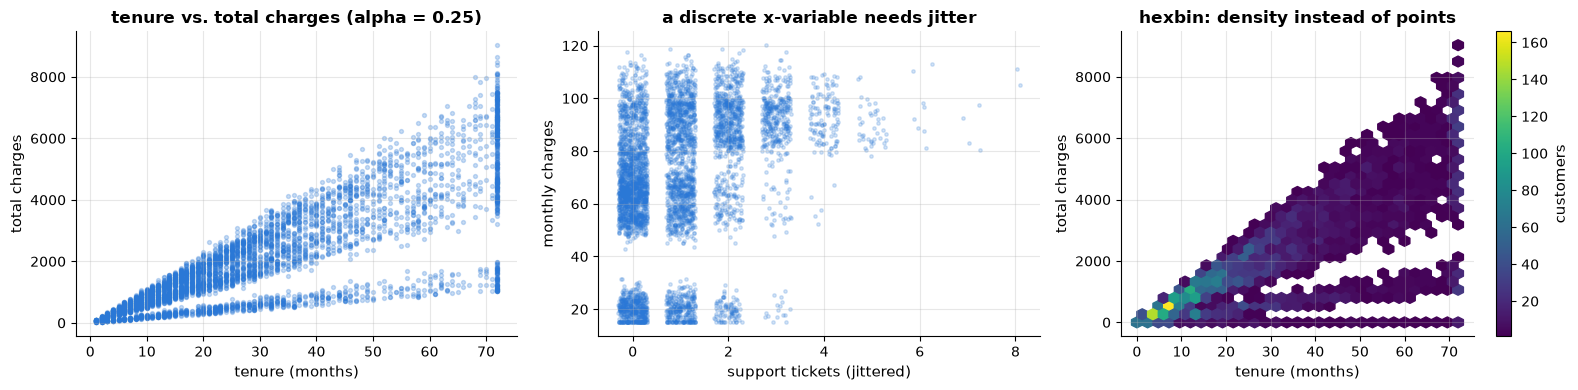

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(df["tenure_months"], df["total_charges"], s=8, alpha=0.25, color=PALETTE[0])   # s: marker size
axes[0].set_xlabel("tenure (months)")
axes[0].set_ylabel("total charges")
axes[0].set_title("tenure vs. total charges (alpha = 0.25)")

jitter = rng.uniform(-0.3, 0.3, len(df))    # a small random shift per customer, so equal ticket counts do not overlap
axes[1].scatter(df["support_tickets"] + jitter, df["monthly_charges"], s=6, alpha=0.2, color=PALETTE[0])
axes[1].set_xlabel("support tickets (jittered)")
axes[1].set_ylabel("monthly charges")
axes[1].set_title("a discrete x-variable needs jitter")

# hexbin counts the points in hexagonal cells: gridsize = number of hexagons across, mincnt=1 leaves empty cells blank;
# .fillna(0) treats a missing total charge as 0
hb = axes[2].hexbin(df["tenure_months"], df["total_charges"].fillna(0), gridsize=30, cmap="viridis", mincnt=1)
axes[2].set_xlabel("tenure (months)")
axes[2].set_ylabel("total charges")
axes[2].set_title("hexbin: density instead of points")
plt.colorbar(hb, ax=axes[2], label="customers")     # the colour scale for the hexagon counts
plt.tight_layout()
plt.show()

The fan shape in the first panel is exactly what `total ≈ monthly × tenure` predicts:
customers on different plans accumulate charges at different rates. The third panel shows
where most customers actually are — the two-dimensional analogue of a histogram.

### 4.2 Correlation: Pearson, Spearman, Kendall

**Pearson's** $r$ measures *linear* association:

$$
r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\,\sqrt{\sum_i (y_i - \bar{y})^2}} \in [-1, 1].
$$

It is $\pm 1$ only for a perfect straight line, it is sensitive to outliers, and it can be
near zero for a perfectly deterministic but non-linear relation. **Spearman's** $\rho$ is
Pearson's $r$ computed on the *ranks* of the values: it measures *monotonic* association,
is robust to outliers and to monotone transformations (a log transform does not change
it). **Kendall's** $\tau$ counts *concordant* minus *discordant* pairs — pairs of
observations ordered the same way on both variables minus those ordered oppositely, as a
fraction of all pairs — and is the most robust and most interpretable of the three, at
the price of $O(n \log n)$ computation and smaller absolute values.

In [15]:
num_cols = ["tenure_months", "monthly_charges", "total_charges", "support_tickets"]
# .corr(method=...) gives the (4, 4) matrix of pairwise correlations; the dict comprehension builds one per method
corr_methods = {m: df[num_cols].corr(method=m) for m in ["pearson", "spearman", "kendall"]}
# from each matrix take the total_charges row (three columns) and put the three methods side by side
pd.DataFrame({m: c.loc["total_charges", ["tenure_months", "monthly_charges", "support_tickets"]] for m, c in corr_methods.items()}).round(3)

,pearson,spearman,kendall
tenure_months,0.821,0.830,0.678
monthly_charges,0.468,0.480,0.332
support_tickets,0.174,0.156,0.117


In [16]:
# where the three disagree: a curved but monotone relation, and one with an outlier
t = np.linspace(0, 3, 200)
curved = np.exp(2 * t)                                     # monotone, strongly non-linear
with_outlier = np.append(rng.normal(size=60), 8)          # 60 unrelated points plus one extreme pair
x_out = np.append(rng.normal(size=60), 8)                 # np.append adds the value 8 at the end of the array
for name, a, b in [("y = exp(2x) (monotone, curved)", t, curved), ("60 unrelated points + 1 outlier", x_out, with_outlier)]:
    # each scipy function returns (coefficient, p-value); [0] keeps the coefficient
    print(f"{name:36s} Pearson {stats.pearsonr(a, b)[0]:+.3f}   Spearman {stats.spearmanr(a, b)[0]:+.3f}   Kendall {stats.kendalltau(a, b)[0]:+.3f}")

y = exp(2x) (monotone, curved)       Pearson +0.818   Spearman +1.000   Kendall +1.000
60 unrelated points + 1 outlier      Pearson +0.544   Spearman +0.076   Kendall +0.039


### 4.3 Anscombe's quartet: why we plot

Anscombe (1973) constructed four data sets of eleven points with *identical* means,
variances, correlation and regression line — and completely different structure. Matejka &
Fitzmaurice (2017) went further, morphing a scatter plot into a dinosaur while holding the
same statistics fixed. The lesson has not aged: a correlation coefficient describes a
straight-line summary, and only the plot tells you whether a straight line was the right
summary.

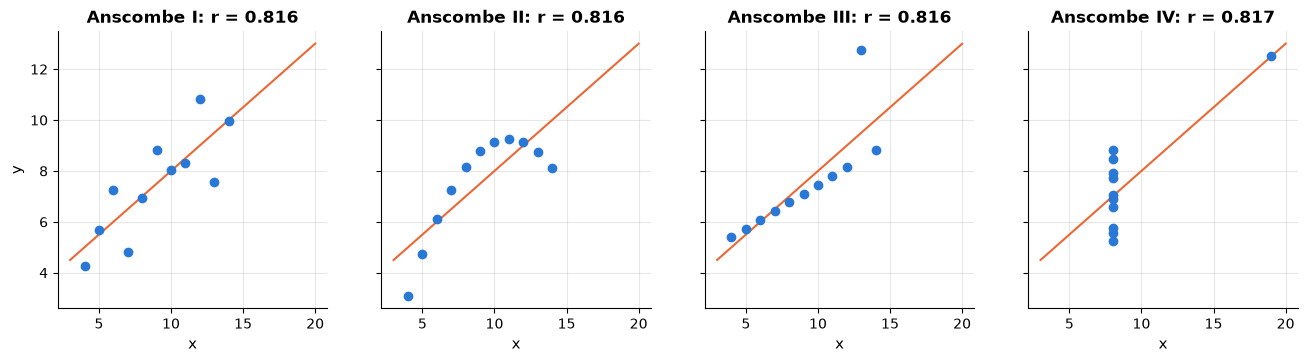

,mean x,var x,mean y,var y,corr,slope,intercept
set,,,,,,,
I,9.0,11.0,7.5,4.13,0.82,0.5,3.0
II,9.0,11.0,7.5,4.13,0.82,0.5,3.0
III,9.0,11.0,7.5,4.12,0.82,0.5,3.0
IV,9.0,11.0,7.5,4.12,0.82,0.5,3.0


In [17]:
# the four data sets: name -> (x values, y values)
anscombe = {
    "I":   ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    "II":  ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    "III": ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    "IV":  ([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]),
}
rows = []
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True, sharey=True)   # all panels use the same axis ranges
for ax, (name, (ax_, ay_)) in zip(axes, anscombe.items()):    # nested unpacking: (name, (x list, y list))
    ax_, ay_ = np.array(ax_, float), np.array(ay_, float)
    # np.polyfit(x, y, 1) fits a straight line by least squares and returns [slope, intercept] (highest power first)
    slope, intercept = np.polyfit(ax_, ay_, 1)
    rows.append({"set": name, "mean x": ax_.mean(), "var x": ax_.var(ddof=1), "mean y": ay_.mean(), "var y": ay_.var(ddof=1),
                 "corr": np.corrcoef(ax_, ay_)[0, 1], "slope": slope, "intercept": intercept})
    ax.scatter(ax_, ay_, color=PALETTE[0], zorder=3)
    xs = np.array([3, 20])
    ax.plot(xs, intercept + slope * xs, color=PALETTE[1], lw=1.5)   # the fitted line, drawn between x = 3 and x = 20
    ax.set_title(f"Anscombe {name}: r = {np.corrcoef(ax_, ay_)[0, 1]:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.show()
pd.DataFrame(rows).set_index("set").round(2)     # a list of dicts becomes one row per dict

### 4.4 Correlation is not causation

Two variables can be correlated because one causes the other, because the other causes
the one, because a third variable — a **confounder** — drives both, or by selection of the
sample. The data alone cannot tell these apart. A tiny simulation shows the confounder
case: a hidden variable $Z$ drives both $X$ and $Y$, which have no causal link, yet they
are strongly correlated; conditioning on $Z$ (here: correlating the residuals after
regressing each on $Z$, the *partial correlation*) removes the association.

In [18]:
n = 2000
z = rng.normal(size=n)                          # e.g. daily temperature
x_ice = 2.0 * z + rng.normal(size=n)            # ice-cream sales, driven by temperature
y_swim = 1.0 * z + rng.normal(size=n)           # swimming-pool incidents, driven by temperature
# what is left of v after removing the straight-line fit on z; np.polyval(coeffs, z) evaluates that line at z
residual = lambda v: v - np.polyval(np.polyfit(z, v, 1), z)
print(f"corr(ice cream, incidents)             = {np.corrcoef(x_ice, y_swim)[0, 1]:+.3f}")
print(f"partial correlation given temperature  = {np.corrcoef(residual(x_ice), residual(y_swim))[0, 1]:+.3f}")

corr(ice cream, incidents)             = +0.639
partial correlation given temperature  = +0.002


For a predictive model a spurious correlation can still be *useful* — the model does not
need to know why ice-cream sales predict pool incidents — but it is fragile (it breaks the
moment the confounder's behaviour changes) and it is fatal for any *causal* claim ("reduce
ice-cream sales to prevent incidents"). Notebooks 17 and 19 return to the difference
between explaining a model and explaining the world.

### 4.5 The correlation heatmap

For many numeric columns, a heatmap of the correlation matrix — diverging colour map
centred at zero, fixed range $[-1, 1]$, annotated, with the redundant upper triangle
masked — is the standard overview. Here we include the binary columns as 0/1 numbers
(their Pearson correlation with a numeric variable is the *point-biserial* correlation,
which is legitimate). Notebook 4 uses this view to find redundant features, notebook 6 to
diagnose multicollinearity.

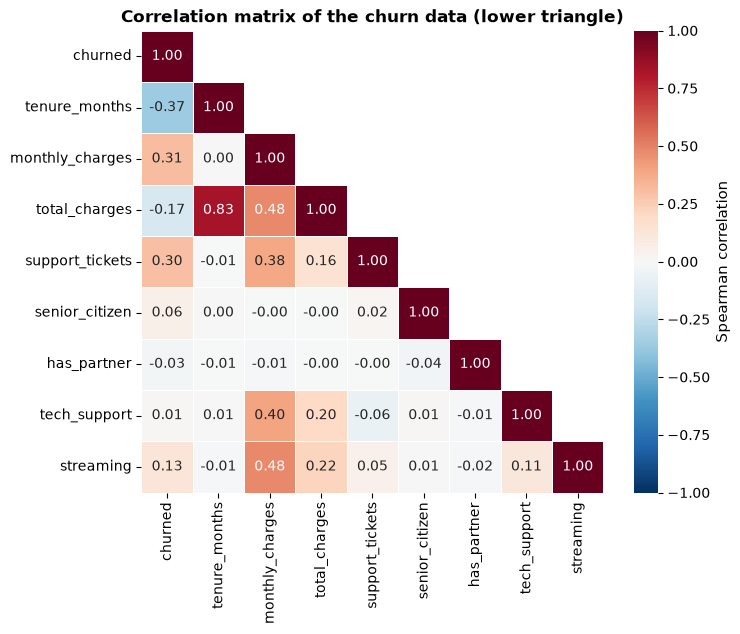

In [19]:
heat_cols = ["churned", "tenure_months", "monthly_charges", "total_charges", "support_tickets",
             "senior_citizen", "has_partner", "tech_support", "streaming"]
corr = df[heat_cols].corr(method="spearman")          # (9, 9) correlation matrix
# np.triu(..., k=1) keeps the part above the diagonal: True there, so the heatmap hides the redundant upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
# center=0 puts the neutral colour at zero; annot/fmt write the values with 2 decimals; square=True makes square cells
sns.heatmap(corr, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set_title("Correlation matrix of the churn data (lower triangle)")
ax.grid(False)
plt.show()

### 4.6 Categorical versus numeric

How does a numeric variable behave in each category? Grouped box plots (or violins) answer
it for the whole distribution; a **conditional mean with a confidence interval** answers it
for the average. For a binary target the conditional mean *is* the churn rate in the group,
and its standard error is $\sqrt{p(1-p)/n}$ — small groups get wide intervals, which is
exactly the warning one needs before reading meaning into a difference.

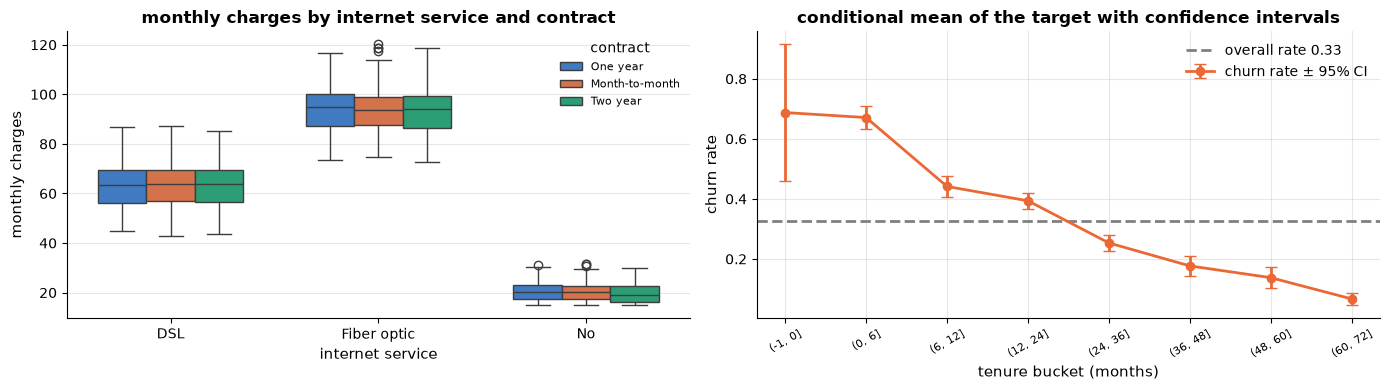

In [20]:
tenure_bins = [-1, 0, 6, 12, 24, 36, 48, 60, 72]
# pd.cut assigns each value to an interval (a, b] between consecutive edges, so (-1, 0] holds exactly tenure 0
df = df.assign(tenure_bucket=pd.cut(df["tenure_months"], bins=tenure_bins))
# churn rate and number of customers per bucket; observed=True keeps only buckets that actually occur
grp = df.groupby("tenure_bucket", observed=True)["churned"].agg(["mean", "size"])
grp["se"] = np.sqrt(grp["mean"] * (1 - grp["mean"]) / grp["size"])     # standard error of a proportion

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# data= plus column names: x groups, y values, hue splits each group into one box per contract type
sns.boxplot(data=df, x="internet_service", y="monthly_charges", hue="contract", ax=axes[0], palette=PALETTE[:3], width=0.7)
axes[0].set_title("monthly charges by internet service and contract")
axes[0].set_xlabel("internet service")
axes[0].set_ylabel("monthly charges")
axes[0].legend(title="contract", fontsize=8)
# errorbar: points with vertical bars of half-length yerr; fmt="o-" = dots joined by a line, capsize = bar-end width
axes[1].errorbar(range(len(grp)), grp["mean"], yerr=1.96 * grp["se"], fmt="o-", color=PALETTE[1], capsize=4, lw=2, label="churn rate ± 95% CI")
axes[1].axhline(df["churned"].mean(), color="gray", ls="--", label=f"overall rate {df['churned'].mean():.2f}")
axes[1].set_xticks(range(len(grp)))
axes[1].set_xticklabels([str(b) for b in grp.index], rotation=30, fontsize=8)   # the intervals as text, e.g. "(0, 6]"
axes[1].set_xlabel("tenure bucket (months)")
axes[1].set_ylabel("churn rate")
axes[1].set_title("conditional mean of the target with confidence intervals")
axes[1].legend()
plt.tight_layout()
plt.show()

Monthly charges depend on the internet plan and barely on the contract; churn depends on
tenure with a sharp early-life spike and a steady decline. The tiny bucket of brand-new
customers (`tenure == 0`) has the widest interval: eleven or twelve customers cannot pin a
rate down.

### 4.7 Categorical versus categorical

Two categorical variables meet in a **contingency table** (`pd.crosstab`). Normalising each
row turns counts into conditional distributions, which a **normalised stacked bar chart**
displays directly. A $\chi^2$ test of independence (`scipy.stats.chi2_contingency`) tells
whether the association could plausibly be chance — with 5 000 rows almost everything is
"significant", so the *size* of the difference matters more than the $p$-value.

churned,0,1,churn_rate
contract,,,
Month-to-month,1469,1325,0.474
One year,986,236,0.193
Two year,913,71,0.072


chi-square test of independence: chi2 = 665.7, dof = 2, p = 2.7e-145


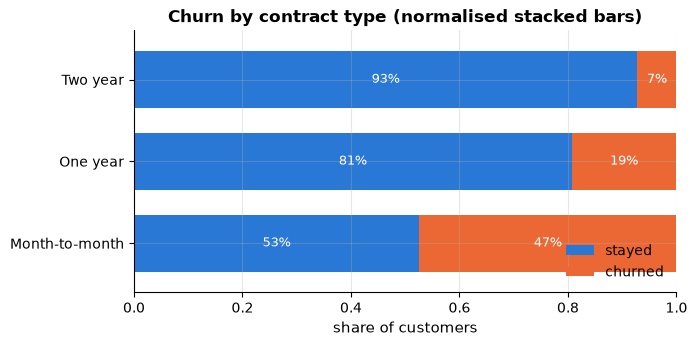

In [21]:
ct = pd.crosstab(df["contract"], df["churned"])                              # counts
ct_norm = pd.crosstab(df["contract"], df["churned"], normalize="index")      # normalize="index": each row sums to 1
# chi2_contingency returns (statistic, p-value, degrees of freedom, expected counts); _ discards the last one
chi2, p_value, dof, _ = stats.chi2_contingency(ct)
display(ct.assign(churn_rate=ct_norm[1].round(3)))    # ct_norm[1] is the column churned = 1
print(f"chi-square test of independence: chi2 = {chi2:.1f}, dof = {dof}, p = {p_value:.2g}")

fig, ax = plt.subplots(figsize=(7, 3.4))
# pandas' own .plot(): one horizontal bar per row, with the two columns stacked end to end
ct_norm.plot(kind="barh", stacked=True, color=[PALETTE[0], PALETTE[1]], ax=ax, width=0.7)
for i, (stay, churn) in enumerate(ct_norm.to_numpy()):      # each row is (share stayed, share churned)
    ax.text(stay / 2, i, f"{stay:.0%}", va="center", ha="center", color="white", fontsize=9)   # centre of each segment
    ax.text(stay + churn / 2, i, f"{churn:.0%}", va="center", ha="center", color="white", fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("share of customers")
ax.set_ylabel("")
ax.set_title("Churn by contract type (normalised stacked bars)")
ax.legend(["stayed", "churned"], loc="lower right")
plt.show()

### 4.8 Target-oriented EDA: churn rate by segment

In a supervised project the most productive bivariate analysis is *every feature against
the target*. For categorical features, plot the churn rate per level with the base rate as a
reference line; for numeric features, bin into quantiles (deciles) and plot the rate per
bin. Levels far from the base rate, and monotone or strongly curved profiles, are where a
model will find its signal — and where a feature that predicts *too* well should make you
suspicious of leakage.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


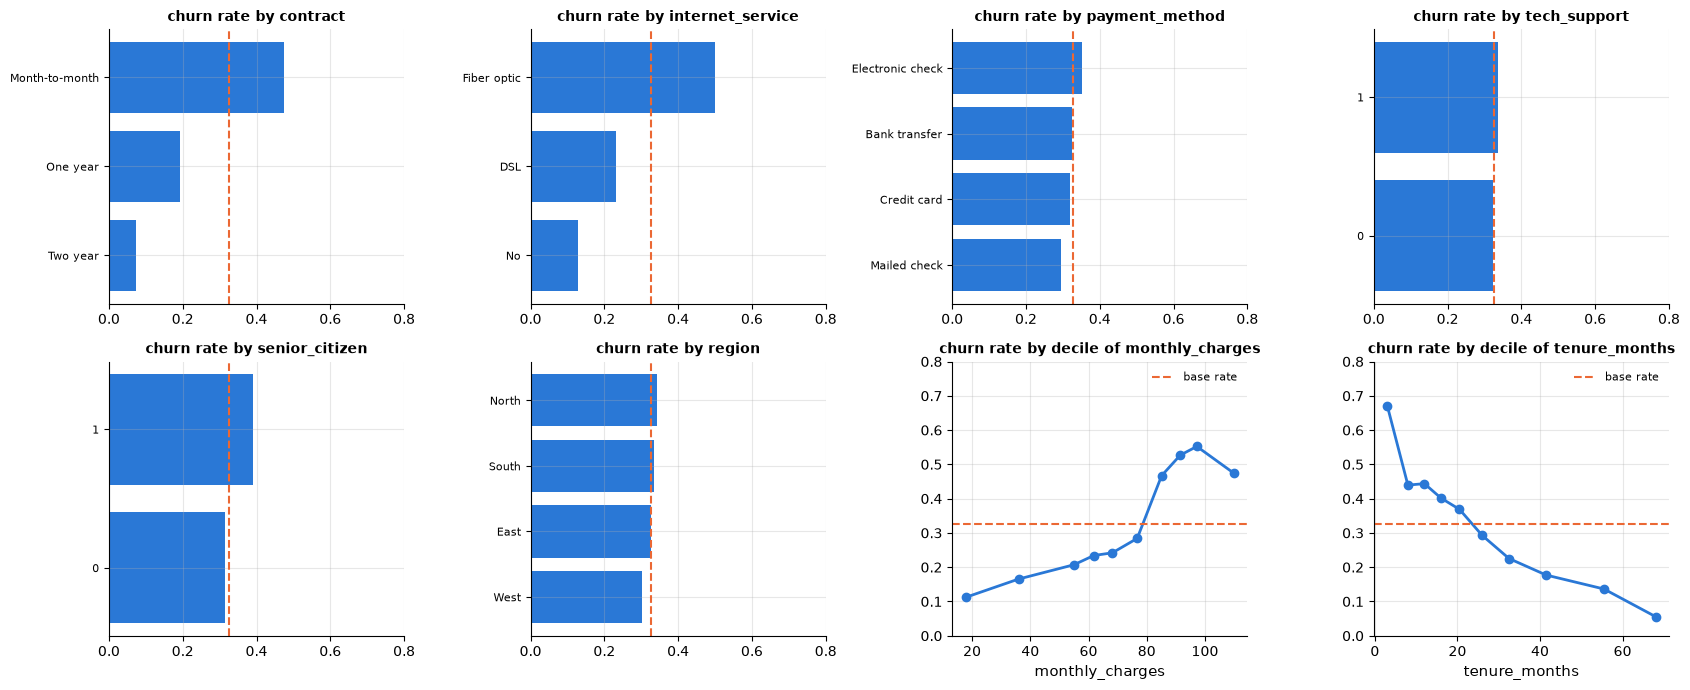

In [22]:
seg_cols = ["contract", "internet_service", "payment_method", "tech_support", "senior_citizen", "region"]
base_rate = df["churned"].mean()
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, col in zip(axes.ravel()[:6], seg_cols):      # .ravel() flattens the 2 x 4 grid; the first six panels
    rate = df.groupby(col, observed=True)["churned"].agg(["mean", "size"]).sort_values("mean")
    ax.barh([str(i) for i in rate.index], rate["mean"], color=PALETTE[0])   # str(): show 0/1 labels as categories
    ax.axvline(base_rate, color=PALETTE[1], ls="--", lw=1.5)
    ax.set_xlim(0, 0.8)
    ax.set_title(f"churn rate by {col}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
for ax, col in zip(axes.ravel()[6:], ["monthly_charges", "tenure_months"]):    # the last two panels
    # pd.qcut cuts into q bins with (about) equal numbers of rows; duplicates="drop" merges bins whose edges coincide
    deciles = pd.qcut(df[col], q=10, duplicates="drop")
    rate = df.groupby(deciles, observed=True)["churned"].mean()
    mids = [iv.mid for iv in rate.index]             # .mid is the midpoint of each interval, used as its x position
    ax.plot(mids, rate.values, marker="o", color=PALETTE[0])
    ax.axhline(base_rate, color=PALETTE[1], ls="--", lw=1.5, label="base rate")
    ax.set_ylim(0, 0.8)
    ax.set_xlabel(col)
    ax.set_title(f"churn rate by decile of {col}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Contract type, internet service, payment method, tech support and tenure carry strong
signal; region carries none (the four bars sit on the base rate); senior citizens churn
somewhat more. Monthly charges show a *rising* profile — in the raw data they are
confounded with the plan (fibre customers pay more *and* churn more), which is the kind of
entanglement that a model, unlike a single-variable plot, can disentangle.

## 5. Multivariate views

### 5.1 Pair plots

A pair plot draws every scatter plot of a set of numeric columns, with distributions on
the diagonal, coloured by a category. It is the fastest way to see all pairwise structure
at once — and it scales badly: $d$ columns give $d^2$ panels, so choose a handful of
features and subsample the rows.

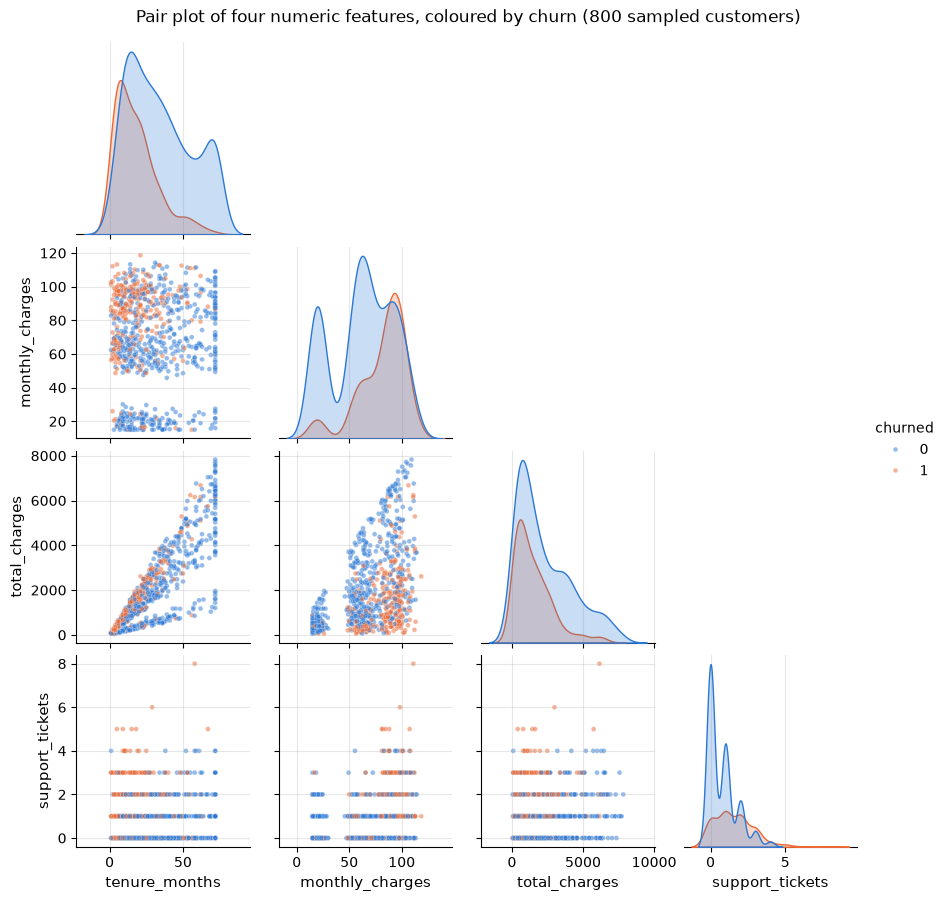

In [23]:
pair_cols = ["tenure_months", "monthly_charges", "total_charges", "support_tickets"]
sample = df.dropna(subset=pair_cols).sample(800, random_state=RANDOM_STATE)   # 800 random complete rows
# sns.pairplot: a grid of scatter plots for every pair of `vars`, coloured by `hue`; plot_kws goes to the scatter calls,
# diag_kind="kde" puts density curves on the diagonal, height is each panel's size, corner=True drops the upper half
g = sns.pairplot(sample, vars=pair_cols, hue="churned", palette={0: PALETTE[0], 1: PALETTE[1]},
                 plot_kws={"s": 12, "alpha": 0.5}, diag_kind="kde", height=2.2, corner=True)
g.figure.suptitle("Pair plot of four numeric features, coloured by churn (800 sampled customers)", y=1.02)
plt.show()

### 5.2 Small multiples and facets

When a relationship might differ between groups, draw it once *per group*, on shared
axes: **small multiples**. seaborn's figure-level functions (`catplot`, `relplot`,
`displot`) do this with `col=` and `row=`. The panels below show that the effect of the
internet plan on churn is present *within every contract type* — the two effects are
additive rather than one masquerading as the other.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


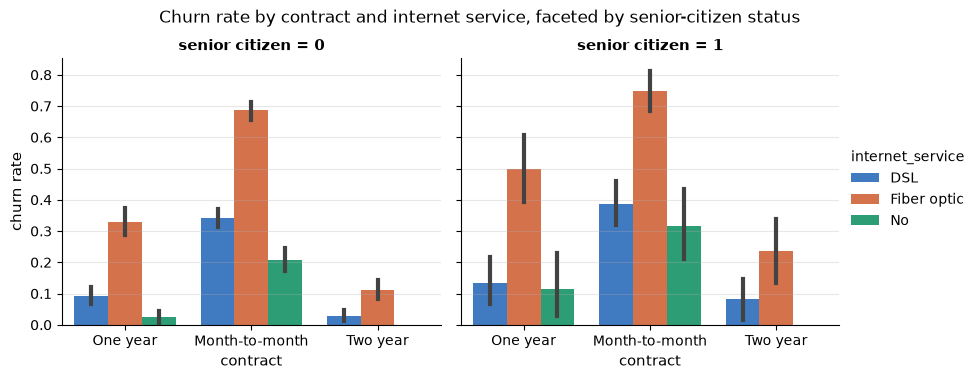

In [24]:
# sns.catplot(kind="bar"): bar height = mean of y per group (here the churn rate); errorbar=("ci", 95) adds 95 %
# bootstrap confidence intervals; col= draws one panel per value; height and aspect set each panel's size and shape
g = sns.catplot(data=df, x="contract", y="churned", hue="internet_service", col="senior_citizen",
                kind="bar", errorbar=("ci", 95), palette=PALETTE[:3], height=3.6, aspect=1.2)
g.set_axis_labels("contract", "churn rate")
g.set_titles("senior citizen = {col_name}")      # {col_name} is a placeholder that seaborn fills in for each panel
g.figure.suptitle("Churn rate by contract and internet service, faceted by senior-citizen status", y=1.04)
plt.show()

### 5.3 Parallel coordinates and a first look at PCA

Beyond three or four dimensions, scatter plots run out of axes. **Parallel coordinates**
draw one vertical axis per variable and one polyline per observation; with standardised
variables and a class colour they show which variables separate the classes. **Principal
component analysis** (PCA) instead projects the data onto the directions of largest
variance (the eigenvectors of the covariance matrix, notebook 2) and lets us draw a
high-dimensional cloud in two dimensions. We try both on the wine data (178 wines,
13 chemical measurements, 3 cultivars) bundled with scikit-learn. Standardising first is
essential: PCA measures variance, and a variable measured in large units would dominate
otherwise. Notebook 14 develops PCA properly.

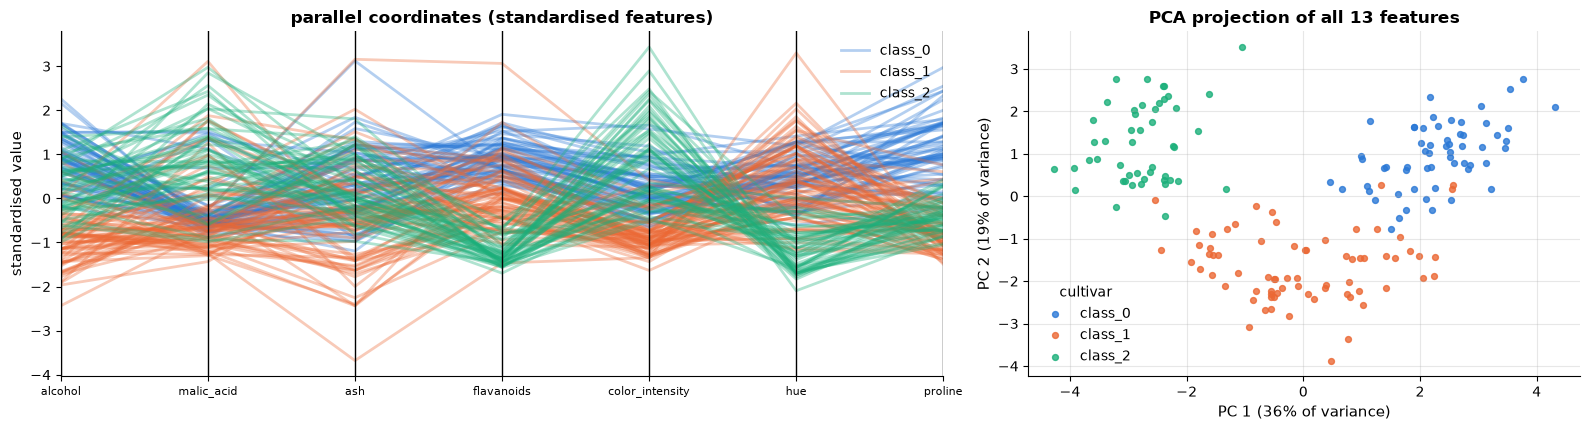

In [25]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

wine = load_wine(as_frame=True)          # 178 wines x 13 measurements; wine.target holds the cultivar 0, 1 or 2
# fit_transform rescales every column to mean 0 and standard deviation 1 and returns a NumPy array, wrapped back here
X_wine = pd.DataFrame(StandardScaler().fit_transform(wine.data), columns=wine.data.columns)
X_wine["cultivar"] = wine.target_names[wine.target]     # index the array of names with the labels: one name per wine

fig, axes = plt.subplots(1, 2, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1.6, 1]})
pc_cols = ["alcohol", "malic_acid", "ash", "flavanoids", "color_intensity", "hue", "proline"]
# one vertical axis per column and one line per wine, coloured by the class column given as the second argument
pd.plotting.parallel_coordinates(X_wine[pc_cols + ["cultivar"]], "cultivar", color=PALETTE[:3], alpha=0.35, ax=axes[0])
axes[0].set_title("parallel coordinates (standardised features)")
axes[0].set_ylabel("standardised value")
axes[0].tick_params(axis="x", labelsize=8)

# PCA(n_components=2) finds the two directions of largest variance; .fit learns them on the 13 feature columns
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_wine[wine.data.columns])
scores = pca.transform(X_wine[wine.data.columns])    # coordinates of every wine on those two directions: (178, 2)
for i, name in enumerate(wine.target_names):
    m = wine.target == i                             # boolean mask: the wines of cultivar i
    axes[1].scatter(scores[m, 0], scores[m, 1], s=18, color=PALETTE[i], label=name, alpha=0.8)
# explained_variance_ratio_[k] is the share of the total variance captured by component k
axes[1].set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
axes[1].set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
axes[1].set_title("PCA projection of all 13 features")
axes[1].legend(title="cultivar")
plt.tight_layout()
plt.show()

Two principal components — a specific linear combination of thirteen measurements — are
enough to separate the three cultivars almost completely; flavanoids, colour intensity and
proline do most of the work, as the parallel coordinates show.

## 6. Time-indexed EDA

Time series need their own toolkit: the *order* of rows carries information, and the
questions are about trend, seasonality (at several periods at once) and anomalies. We
use two years of hourly electricity demand with temperature and a holiday flag. Setting the
timestamp as the index unlocks pandas' time-series machinery: `resample` aggregates to
coarser frequencies, `rolling` computes moving windows, and `.index.hour` / `.dayofweek` /
`.month` extract calendar components for seasonal profiles. Notebook 16 builds forecasting
models on top of exactly these views.

2022-01-01 00:00:00 -> 2023-12-31 23:00:00 | 17520 hourly rows | frequency: h


,demand_mw,temperature_c,is_holiday
count,17520.0,17520.0,17520.0
mean,602.6,9.9,0.0
std,84.1,9.1,0.1
min,316.1,-15.3,0.0
25%,543.2,2.8,0.0
50%,598.0,9.9,0.0
75%,659.4,17.0,0.0
max,920.2,33.1,1.0


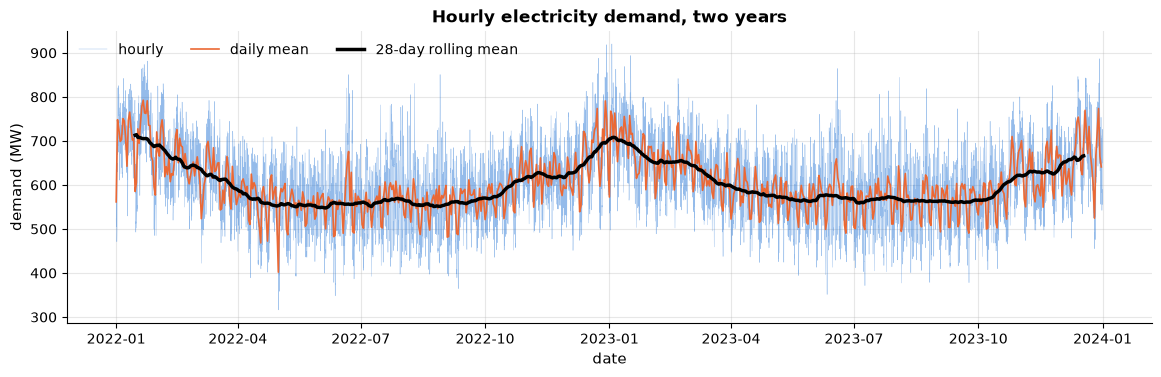

In [26]:
energy = load_energy_demand().set_index("timestamp")    # the timestamps become the row index (a DatetimeIndex)
# pd.infer_freq guesses the regular spacing of the index ("h" = hourly)
print(energy.index.min(), "->", energy.index.max(), "|", len(energy), "hourly rows | frequency:", pd.infer_freq(energy.index))
display(energy.describe().round(1))

daily = energy["demand_mw"].resample("D").mean()    # resample("D") groups the hours by calendar day; .mean() per day
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(energy.index, energy["demand_mw"], lw=0.3, alpha=0.5, color=PALETTE[0], label="hourly")
ax.plot(daily.index, daily, lw=1.2, color=PALETTE[1], label="daily mean")
# rolling(28, center=True).mean(): the average of a 28-day window centred on each day (NaN where it is incomplete)
ax.plot(daily.index, daily.rolling(28, center=True).mean(), lw=2.5, color="black", label="28-day rolling mean")
ax.set_xlabel("date")
ax.set_ylabel("demand (MW)")
ax.set_title("Hourly electricity demand, two years")
ax.legend(loc="upper left", ncol=3)
plt.show()

Three time scales are visible at once: the hourly wiggle (a daily cycle), the weekly
pattern in the daily means, and an annual cycle with winter and summer peaks plus a slight
upward trend. **Seasonal profiles** isolate each cycle by averaging over the others — the
hour-of-day × day-of-week heatmap is the standard view for load data:

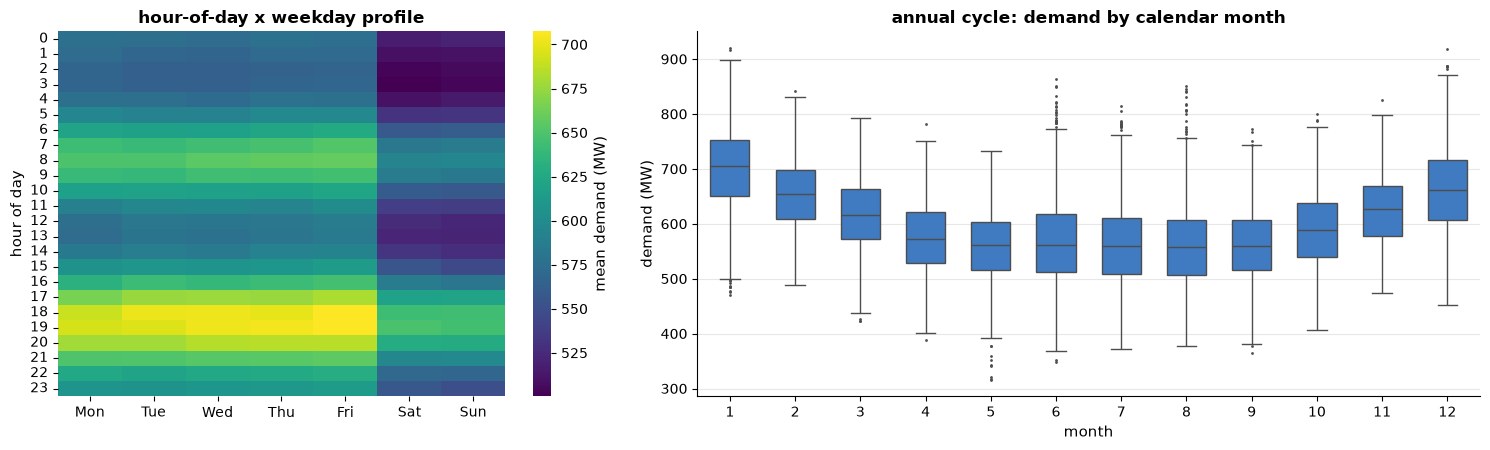

In [27]:
# calendar parts of the index as new columns: hour 0-23, dayofweek 0 (Monday) to 6 (Sunday), month 1-12
profile = energy.assign(hour=energy.index.hour, weekday=energy.index.dayofweek, month=energy.index.month)
heat = profile.pivot_table(values="demand_mw", index="hour", columns="weekday", aggfunc="mean")   # (24, 7) table
heat.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]    # rename the columns 0..6

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1, 1.4]})
sns.heatmap(heat, cmap="viridis", ax=axes[0], cbar_kws={"label": "mean demand (MW)"})
axes[0].set_title("hour-of-day x weekday profile")
axes[0].set_xlabel("")
axes[0].set_ylabel("hour of day")
axes[0].grid(False)
# one box per month; fliersize is the size of the dots drawn for outliers
sns.boxplot(data=profile, x="month", y="demand_mw", ax=axes[1], color=PALETTE[0], fliersize=1, width=0.6)
axes[1].set_title("annual cycle: demand by calendar month")
axes[1].set_xlabel("month")
axes[1].set_ylabel("demand (MW)")
plt.tight_layout()
plt.show()

The heatmap shows the double daily peak (morning and early evening), the weekend dip, and
that Saturday and Sunday lose the morning peak entirely; the monthly boxes show the winter
and summer maxima with mild shoulder seasons. The relationship to temperature is the
bivariate view a forecasting model will exploit:

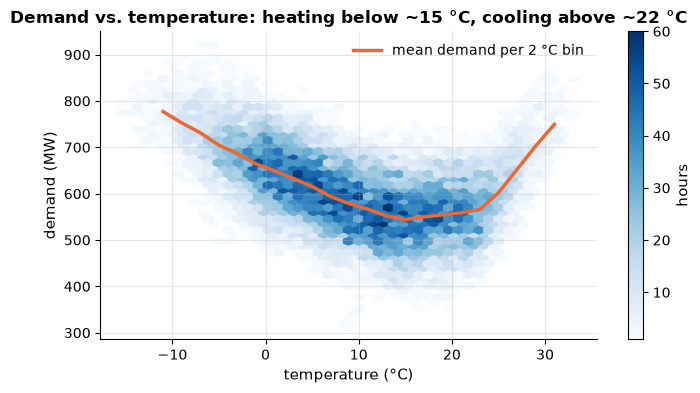

mean weekday demand: holidays 556 MW vs. other weekdays 620 MW (-10.4%)


In [28]:
temp_bins = pd.cut(energy["temperature_c"], bins=np.arange(-12, 36, 2))    # 2 °C bins with edges -12, -10, ..., 34
binned = energy.groupby(temp_bins, observed=True)["demand_mw"].agg(["mean", "size"])
binned = binned[binned["size"] >= 20]                 # keep only bins with at least 20 hours of data
# Monday to Friday only (weekday < 5), then mean demand for is_holiday = 0 and is_holiday = 1
holiday_effect = energy.assign(weekday=energy.index.dayofweek).query("weekday < 5").groupby("is_holiday")["demand_mw"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
hb = ax.hexbin(energy["temperature_c"], energy["demand_mw"], gridsize=45, cmap="Blues", mincnt=1)
ax.plot([iv.mid for iv in binned.index], binned["mean"], color=PALETTE[1], lw=2.5, label="mean demand per 2 °C bin")
ax.set_xlabel("temperature (°C)")
ax.set_ylabel("demand (MW)")
ax.set_title("Demand vs. temperature: heating below ~15 °C, cooling above ~22 °C")
ax.legend()
plt.colorbar(hb, ax=ax, label="hours")
plt.show()
# holiday_effect[1] / [0] select by label (is_holiday = 1 / 0); :+.1% prints a signed percentage
print(f"mean weekday demand: holidays {holiday_effect[1]:.0f} MW vs. other weekdays {holiday_effect[0]:.0f} MW "
      f"({holiday_effect[1] / holiday_effect[0] - 1:+.1%})")

## 7. Pitfalls

### 7.1 Simpson's paradox

An association that holds in every subgroup can reverse when the subgroups are pooled
(Simpson, 1951). It happens whenever group membership is correlated with *both* the
treatment and the outcome. We construct the classic version: a retention offer that
*lowers* churn within every contract type, yet appears to *raise* it overall, because the
offer was targeted at the segment most likely to churn anyway.

offer,no offer,offer
Month-to-month,0.495,0.391
Two year,0.080,0.046
ALL customers,0.222,0.348


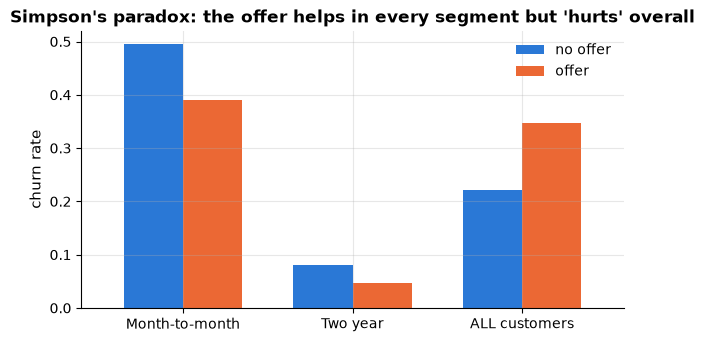

In [29]:
segments = {  # contract: (customers, share who received the offer, churn rate with offer, churn rate without)
    "Month-to-month": (3000, 0.70, 0.40, 0.52),
    "Two year":       (2000, 0.15, 0.04, 0.08),
}
rows = []
for contract, (n, offer_share, churn_offer, churn_none) in segments.items():
    got_offer = rng.random(n) < offer_share          # True for about offer_share of the customers
    # np.where(cond, a, b) picks from a where cond is True and from b elsewhere: each customer churns with the rate
    # of their group
    churned = np.where(got_offer, rng.random(n) < churn_offer, rng.random(n) < churn_none)
    # the single value `contract` is repeated for every row of the frame
    rows.append(pd.DataFrame({"contract": contract, "offer": np.where(got_offer, "offer", "no offer"), "churned": churned.astype(int)}))
campaign = pd.concat(rows, ignore_index=True)        # stack the frames; ignore_index renumbers the rows 0..n-1

by_segment = campaign.pivot_table(values="churned", index="contract", columns="offer", aggfunc="mean")
# pooled churn rate per offer group, turned into a one-row frame: .to_frame() gives one column, .T makes it a row,
# and .rename(index=...) changes that row's label
overall = campaign.groupby("offer")["churned"].mean().to_frame().T.rename(index={"churned": "ALL customers"})
table = pd.concat([by_segment, overall])             # append the pooled row under the two segment rows
display(table.round(3))

fig, ax = plt.subplots(figsize=(7, 3.6))
table[["no offer", "offer"]].plot(kind="bar", ax=ax, color=[PALETTE[0], PALETTE[1]], width=0.7, rot=0)   # rot=0: flat labels
ax.set_ylabel("churn rate")
ax.set_title("Simpson's paradox: the offer helps in every segment but 'hurts' overall")
ax.legend(title="")
plt.show()

The resolution is not statistical but *causal*: the pooled comparison compares mostly
month-to-month customers (who got the offer) with mostly two-year customers (who did not).
Whenever you compare groups, ask what else differs between them — and stratify.

### 7.2 Survivorship and selection bias

A data set is a *sample*, and how it was sampled shapes every pattern in it. The best
known story is Wald's analysis of returning WWII bombers: armour was proposed for the
places with the most bullet holes, until he pointed out that the sample contained only the
planes that *survived* their hits — the unmarked areas were the fatal ones. Our churn table
has the same structure in miniature: it contains only customers who existed at extraction
time (the signup histogram of notebook 1 showed the 72-month cap), `total_charges` exists
only for customers who have been billed, and any model trained on it learns about *these*
customers, under *these* prices and competitors. A classifier trained on loan applicants
who were *approved* (notebook 19) knows nothing about those who were rejected. The
question "who is missing from this table, and why?" belongs in every EDA report.

### 7.3 Misleading axes

The same numbers can be made to tell opposite stories with an axis. A bar chart's $y$-axis
must start at zero — bars encode *length*, and truncating the axis exaggerates differences
(Wainer, 1984, catalogues this and eleven other ways to display data badly). Dual
$y$-axes let the author choose which two scales make the lines cross; area and 3-D
effects distort perceived magnitudes. The churn rates by region below differ by a few
points and are statistically indistinguishable — one axis says so, the other shouts.

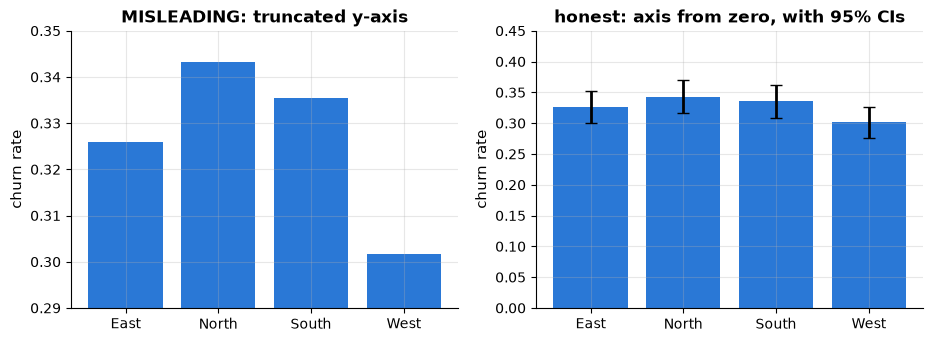

In [30]:
region_rate = df.groupby("region")["churned"].agg(["mean", "size"])
region_rate["se"] = np.sqrt(region_rate["mean"] * (1 - region_rate["mean"]) / region_rate["size"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (title, ylim) in zip(axes, [("MISLEADING: truncated y-axis", (0.29, 0.35)), ("honest: axis from zero, with 95% CIs", (0, 0.45))]):
    # error bars only in the honest panel: the "... if condition else None" expression passes None otherwise
    ax.bar(region_rate.index, region_rate["mean"], color=PALETTE[0], yerr=1.96 * region_rate["se"] if ylim[0] == 0 else None, capsize=4)
    ax.set_ylim(*ylim)                 # *ylim unpacks the (bottom, top) pair into two arguments
    ax.set_ylabel("churn rate")
    ax.set_title(title)
plt.show()

### 7.4 A checklist for an EDA report

1. **Provenance**: where the data come from, what a row is, the time span, how the sample
   was selected, and who is *not* in it.
2. **Schema**: every column with type, unit, meaning, plausible range and cardinality.
3. **Quality log**: duplicates, missing values (with their mechanism), inconsistent
   categories, impossible values, the tenure-cap type of artefact — and the decision for
   each.
4. **Target**: its distribution and base rate; candidate leaks.
5. **Univariate**: a distribution plot per variable, with robust summaries; skew and
   suggested transforms.
6. **Bivariate**: correlations among features, every feature against the target, at least
   one stratified view to guard against Simpson-type reversals.
7. **Multivariate / temporal**: pair plots or a PCA view; seasonal profiles for time series.
8. **Open questions** for the domain expert, and the implications for modelling (metric,
   validation scheme, features to engineer).

## Summary

- EDA is detective work with a fixed list of questions: what is a row, what is the target,
  what is each column, what is missing and why, how is everything distributed and related,
  who is not in the sample.
- First contact: `shape`, `dtypes`, `memory_usage`, `describe`, `nunique`, `sample`,
  `isna` (with a missingness matrix), `duplicated`, `value_counts` — and a written
  data-quality log. In the churn file: 5 duplicates, 8 spellings of 4 regions, 3
  impossible charges, structured missingness in `total_charges`, a tenure cap.
- Univariate: histograms with several bin widths, KDEs, log axes for skew, violins where
  box plots hide modes; robust statistics (median, IQR, MAD) resist outliers; the IQR and
  $z$-score rules are heuristics that fail on multimodal and discrete data.
- Bivariate: scatter plots with `alpha`/jitter/hexbin; Pearson (linear), Spearman
  (monotone), Kendall (concordance); Anscombe's quartet says *plot it*; correlation is
  not causation; conditional means with confidence intervals; cross-tabs and normalised
  stacked bars; churn rate by segment against the base rate.
- Multivariate: pair plots on a subset, facets to check that effects hold within groups,
  parallel coordinates and PCA to see high-dimensional structure.
- Time series: `resample`, `rolling`, seasonal profiles by hour × weekday and by month,
  the driver relationship (temperature).
- Pitfalls: Simpson's paradox (stratify!), survivorship/selection bias (who is missing?),
  truncated axes and other lie factors.

| Question | Plot / tool |
|---|---|
| distribution of one numeric variable | `ax.hist` (try several `bins`), `sns.kdeplot`, `sns.violinplot`; log axis if skewed |
| distribution of one categorical variable | sorted `barh` of `value_counts()` |
| outliers | IQR rule, robust $z$-score, and the data dictionary |
| two numeric variables | `scatter(alpha=…)`, jitter, `hexbin`; `df.corr(method=…)` |
| many numeric variables | `sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1)`, `sns.pairplot` (subset), PCA |
| numeric by category | grouped `sns.boxplot`/`violinplot`; conditional means ± CI |
| category by category | `pd.crosstab(normalize="index")`, normalised stacked bars, $\chi^2$ |
| feature vs. binary target | rate per level / per decile vs. base rate |
| effect within subgroups | `sns.catplot(col=…)` facets — the Simpson check |
| time series | `resample("D").mean()`, `rolling(k)`, `pivot_table(index=hour, columns=weekday)` |
| missing data | `isna().sum()`, missingness matrix sorted by a candidate cause |

**Next steps:** notebook 4 (preprocessing and feature engineering) turns the quality log
into a cleaning pipeline and the target-oriented findings into features; notebook 13
(anomaly detection) treats outliers as a modelling problem; notebook 14 (dimensionality
reduction) develops PCA and non-linear alternatives for visualisation; notebook 16 (time
series) builds forecasting models on the energy data; notebook 19 discusses selection bias
and its consequences for fairness.

## Exercises

### Exercise 1 — EDA of the penguins (easy)
Load `course_utils.load_penguins()` (Palmer penguins; a synthetic stand-in appears when
offline). Run the first-contact checks of section 2, plot the distribution of each numeric
measurement per species (grouped box or violin plots), and draw the scatter plot of
`flipper_length_mm` against `body_mass_g` coloured by species and with `sex` as the marker
style. Which single measurement separates the species best?

<details><summary>Solution sketch</summary>

`penguins.isna().sum()` shows a few missing measurements and sexes; `sns.pairplot(penguins,
hue="species")` and `sns.scatterplot(..., hue="species", style="sex")`. Flipper length
(and bill depth) separate Gentoo from the other two almost perfectly; bill length separates
Adelie from Chinstrap.
</details>

### Exercise 2 — Find every data-quality issue in the churn file (easy)
Write a function `quality_report(df)` that returns a table with, for every column: dtype,
number and share of missing values, number of distinct values, and — for numeric columns —
min, max and the number of values flagged by the IQR rule. Run it on `load_churn(raw=True)`
and list every issue it surfaces, plus at least one issue it *cannot* surface (hint: think
about consistency between columns, and about the cap on tenure).

<details><summary>Solution sketch</summary>

Build the table with `df.dtypes`, `df.isna().sum()`, `df.nunique()`, `df.describe()` and
`iqr_flags`. It finds the missing `total_charges`, the 999s and the 8 region spellings (via
`nunique`), but not the duplicated rows (needs `duplicated()`), the tenure cap (needs domain
knowledge or the signup-date histogram), or the `total ≈ monthly × tenure` consistency
check (needs a cross-column rule).
</details>

### Exercise 3 — Simpson's paradox in the churn data (medium)
Using `load_churn()`, compute the churn rate of customers with and without `tech_support`
(a) overall, (b) within each `internet_service` level. Then do the same for `streaming`.
Do you find a reversal, an attenuation, or neither? Explain the pattern with a stratified
bar chart, and explain which variable plays the role of the confounder.

<details><summary>Solution sketch</summary>

`df.groupby(["internet_service", "tech_support"])["churned"].mean().unstack()`. Customers
without internet have neither tech support nor streaming *and* churn least, so the pooled
"no tech support" group is diluted by them: the overall effect of tech support is smaller
than the within-plan effect (attenuation rather than reversal); for streaming the pooled
comparison can even suggest streaming *increases* churn while within fibre/DSL the effect is
negligible. The internet plan is the confounder.
</details>

### Exercise 4 — Temperature profiles of the energy data (medium)
Reproduce the hour × weekday heatmap of section 6 for *temperature* instead of demand, and
then compute a heatmap of the demand *residual* after subtracting the hour-of-day × weekday
mean profile. Which structure remains in the residual (plot it against temperature and
against the date)?

<details><summary>Solution sketch</summary>

`profile.groupby(["hour", "weekday"])["demand_mw"].transform("mean")` gives the profile
value for every row; the residual `demand - profile` still shows the annual cycle and the
U-shaped temperature dependence — the calendar profile explains the daily/weekly cycles but
not the weather. That is the decomposition a forecasting model (notebook 16) must learn.
</details>

### Exercise 5 — A dashboard-like figure (hard)
Design a single figure with `plt.subplots` and `gridspec_kw` (or `fig.add_gridspec`) that
summarises the churn data for a manager: the base rate as a large number, churn rate by
contract and by internet plan, the tenure profile with confidence intervals, and the
monthly-charge distribution of churned vs. retained customers. Apply the rules of section
1.1: one message per panel, axes from zero for bars, a shared colour meaning across panels,
no chart junk. Then write three sentences of findings a manager could act on.

<details><summary>Solution sketch</summary>

```py
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3)
ax_big = fig.add_subplot(gs[0, 0]); ax_big.text(0.5, 0.5, f"{base_rate:.0%}", fontsize=48, ha="center"); ax_big.axis("off")
ax1 = fig.add_subplot(gs[0, 1]); ...
```
Findings: month-to-month fibre customers paying by electronic check churn at more than
twice the base rate; the first six months are decisive; tech support halves churn within
each plan — a retention offer should target new month-to-month fibre customers.
</details>

## References and further reading

### Textbooks

- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. — The book that named the field; stem-and-leaf displays and box plots were introduced here, and its attitude — look first, hypothesise later — is the point of this notebook.
- Tufte, E. R. (2001). *The Visual Display of Quantitative Information* (2nd ed.). Graphics Press. — Data–ink ratio, chart junk, the lie factor, small multiples; the classic on graphical integrity.
- Wilke, C. O. (2019). *Fundamentals of Data Visualization*. O'Reilly. (free at https://clauswilke.com/dataviz/) — A practical, opinionated guide to choosing and designing charts; chapters 7–9 (distributions), 12 (associations), 19 (colour pitfalls) map directly onto this notebook.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly. (free) — Chapters 7 (data cleaning), 9 (plotting), 10 (aggregation) and 11 (time series) are the pandas mechanics used here.
- VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O'Reilly. (free) — Part 4 (Matplotlib) and the seaborn chapter; part 3 for `groupby`/`pivot_table`.

### Papers

- Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician*, 27(1), 17–21. — The quartet of section 4.3.
- Matejka, J., & Fitzmaurice, G. (2017). Same stats, different graphs: generating datasets with varied appearance and identical statistics through simulated annealing. *Proceedings of CHI 2017*, 1290–1294. — The "datasaurus dozen", Anscombe's idea taken to its logical conclusion.
- Cleveland, W. S., & McGill, R. (1984). Graphical perception: theory, experimentation, and application to the development of graphical methods. *Journal of the American Statistical Association*, 79(387), 531–554. — The experiments behind "position beats length beats area beats colour".
- Wainer, H. (1984). How to display data badly. *The American Statistician*, 38(2), 137–147. — Twelve rules for bad graphics, each illustrated; funny and instructive.
- Simpson, E. H. (1951). The interpretation of interaction in contingency tables. *Journal of the Royal Statistical Society: Series B*, 13(2), 238–241. — The paradox of section 7.1.
- Rubin, D. B. (1976). Inference and missing data. *Biometrika*, 63(3), 581–592. — The MCAR/MAR/MNAR taxonomy of missingness mechanisms.
- Wickham, H. (2010). A layered grammar of graphics. *Journal of Computational and Graphical Statistics*, 19(1), 3–28. — The grammar behind ggplot2, and the mental model behind seaborn's figure-level functions.
- Hunter, J. D. (2007). Matplotlib: a 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. — The library behind every figure in this course.
- Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
- Okabe, M., & Ito, K. (2008). Color universal design (CUD): how to make figures and presentations that are friendly to colorblind people. https://jfly.uni-koeln.de/color/ — The reasoning behind colour-blind-safe palettes such as the course `PALETTE`.

### Documentation and online resources (all free)

- pandas user guide, *Visualization*, *Group by* and *Time series / date functionality* — https://pandas.pydata.org/docs/user_guide/
- seaborn tutorial, *An introduction to seaborn* and the *API overview* (figure-level vs. axes-level functions) — https://seaborn.pydata.org/tutorial.html
- Matplotlib, *Choosing colormaps* (why `viridis` and `RdBu_r`) — https://matplotlib.org/stable/users/explain/colors/colormaps.html
- The *Datasaurus Dozen* page — https://www.research.autodesk.com/publications/same-stats-different-graphs/ — Animated companion to Matejka & Fitzmaurice (2017).